In [ ]:
import ast
import inspect
import qsample as qs
import matplotlib.pyplot as plt
import stim
import numpy as np

class ProtocolTranslator(ast.NodeTransformer):
    def __init__(self, fault_tolerant=False):

        self.check_functions = {}
        self.mapping = {}
        
        self.last_functions = []  
        self.condition_stack = ["True"]

        self.protocol = qs.Protocol(check_functions=self.check_functions, fault_tolerant=fault_tolerant)

    def is_stim_circuit_def(self, node):
        if not isinstance(node, ast.Call):
            return False

        f = node.func
        return (
            isinstance(f, ast.Attribute)
            and isinstance(f.value, ast.Name)
            and f.value.id == "stim"
            and f.attr == "Circuit"
        )

    def is_do_circuit(self, node):
        return (
            isinstance(node, ast.Call)
            and isinstance(node.func, ast.Attribute)
            and node.func.attr == "do_circuit"
        )
    
    def is_current_measurement(self, node):
        return (
            isinstance(node, ast.Call)
            and isinstance(node.func, ast.Attribute)
            and node.func.attr == "current_measurement_record"
        )
    
    def visit_Assign(self, node): # MUDAR AQUI DE LAST_CIRCUIT PARA O CIRCUITO QUE DE FATO RODA
        self.collect_circuit(node.targets, node.value)
        if self.last_functions and self.is_current_measurement(node.value):
            target = node.targets[0]
            if isinstance(target, ast.Name):
                self.mapping[target.id] = self.last_functions[0]

        return self.generic_visit(node)

    def visit_If(self, node):
        self.visit(node.test)
        cond_src = ast.unparse(node.test)
        before_if = self.last_functions.copy()
        self.condition_stack[-1]=cond_src


        if isinstance(node.test, ast.Call): # Selects check_functions
            if isinstance(node.test.func, ast.Name):
                    func_name = node.test.func.id
                    real_func = self.globals[func_name]
                    self.check_functions[func_name] = real_func



        
        for stmt in node.body:
            self.visit(stmt)
        after_if = self.last_functions.copy()
        after_if_conds = self.condition_stack.copy()
        
        # ELSE 

        cond_src = f"not {cond_src}"
        self.last_functions = before_if.copy()
        self.condition_stack[-1]=cond_src
    
        has_else=False
        for stmt in node.orelse:
            has_else=True
            self.visit(stmt)

        after_else = self.last_functions.copy()
        after_else_conds = self.condition_stack.copy()
        
        if has_else:
            self.last_functions = after_if + after_else
            self.condition_stack = after_if_conds + after_else_conds
        else:
            self.last_functions = before_if + after_if
            self.condition_stack = [cond_src] + after_if_conds
        return node

    def visit_Expr(self, node):
        if isinstance(node.value, ast.Call) and self.is_do_circuit(node.value):
            if node.value.args and isinstance(node.value.args[0], ast.Name):
                circuit_name = node.value.args[0].id
                if not self.last_functions:
                    self.protocol.add_edge("START", circuit_name, check="True")
                else:
                    for protocol_node, protocol_check in zip(self.last_functions, self.condition_stack):
                        self.protocol.add_edge(protocol_node, circuit_name, check=protocol_check)
                self.last_functions=[circuit_name]
                self.condition_stack=["True"]

        return self.generic_visit(node)
    
    
    def visit_Return(self, node):
        if isinstance(node.value, ast.Constant):
            if node.value.value == "FAIL":
                for protocol_node, protocol_check in zip(self.last_functions, self.condition_stack):
                        self.protocol.add_edge(protocol_node, "FAIL", check=protocol_check)
        self.generic_visit(node)

    def visit_Name(self, node):
        if node.id in self.mapping.keys() and isinstance(node.ctx, ast.Load):
            return ast.copy_location(ast.Name(id=self.mapping[node.id], ctx=node.ctx), node)
        return node
    

    def collect_circuit(self, targets, value):
        if self.is_stim_circuit_def(value):
            for t in targets:
                if isinstance(t, ast.Name):
                    circuit_name=t.id

            if value.args and isinstance(value.args[0], ast.Constant) and isinstance(value.args[0].value, str):
                circuit_text = value.args[0].value
                try:
                    circuit = qs.Circuit().from_stim_circuit(circuit_text)
                    self.protocol.add_node(circuit_name, circuit=circuit)
                    
                    
                except Exception as e:
                    print(f"Failed to parse stim.Circuit at line {value.lineno}: {e}")


[('ENC', 'Z2'), ('ENC', 'meas'), ('Z2', 'X_COR'), ('Z2', 'meas'), ('meas', 'FAIL'), ('X_COR', 'meas'), ('START', 'ENC')]


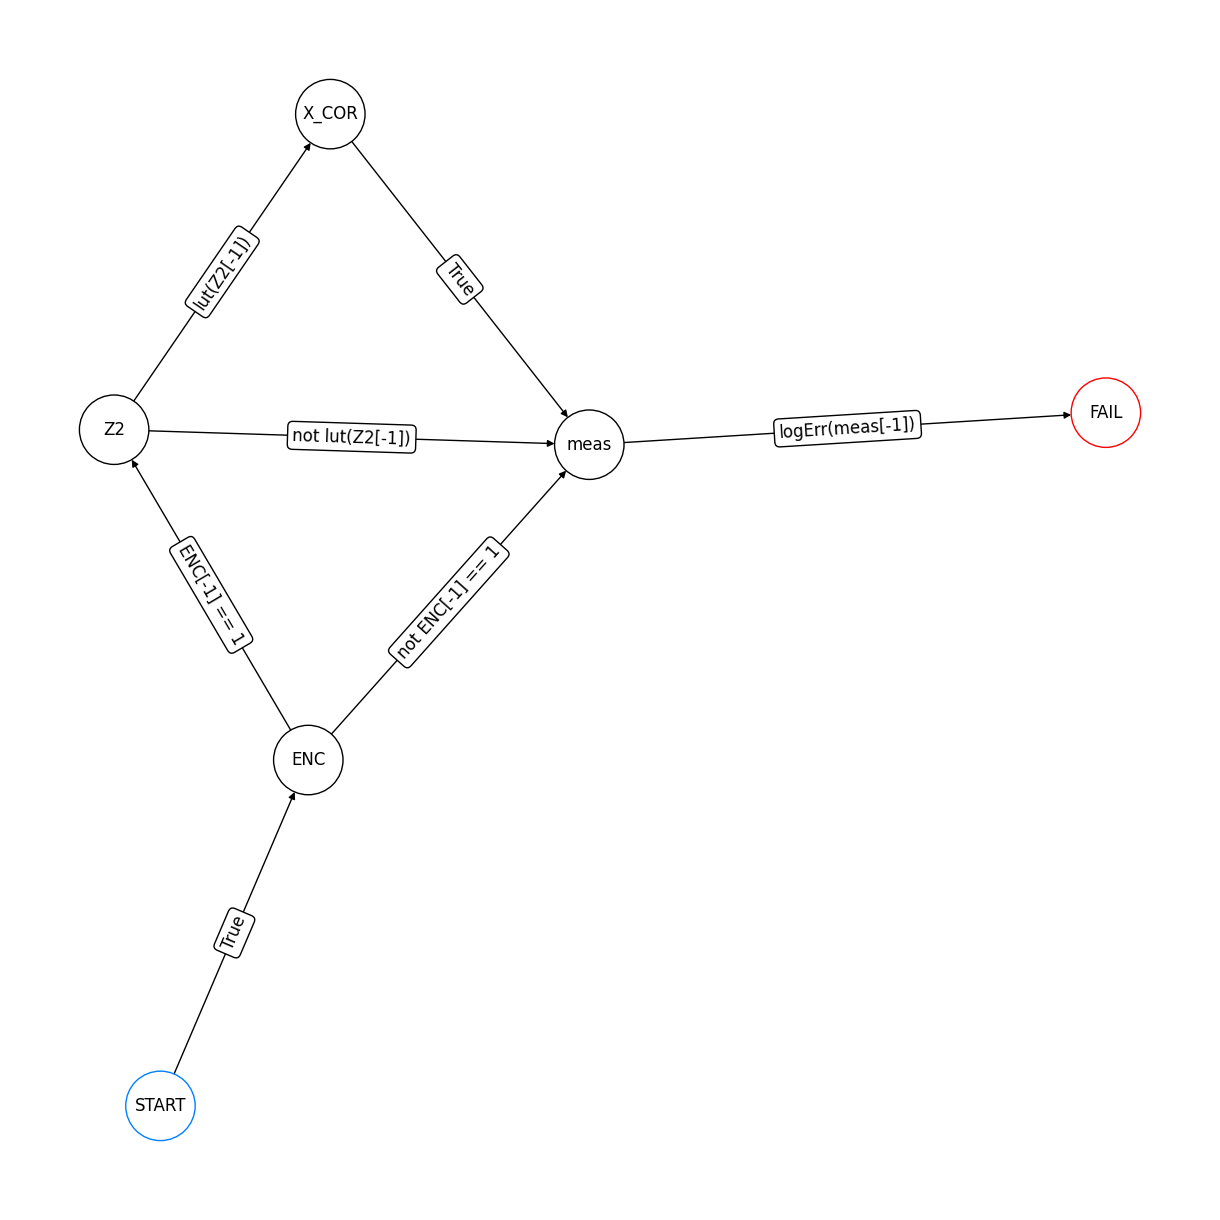

In [29]:
fails = []

def logErr(out):
    global fails
    c = np.array([hamming2(out, i) for i in stabilizerSet])
    d = np.flatnonzero(c <= 1)
    e = np.array([hamming2(out ^ (0b1111111), i) for i in stabilizerSet])
    f = np.flatnonzero(e <= 1)
    if len(d) != 0:
        return False
    elif len(f) != 0:
        fails.append(out)
        return True
    if len(d) != 0 and len(f) != 0: 
        raise('-!-!-CANNOT BE TRUE-!-!-')

def lut(z):
    s = [z]

    if s == [1]:
        return True
    else: 
        return False
    
k1 = 0b0001111
k2 = 0b1010101
k3 = 0b0110011
k12 = k1 ^ k2
k23 = k2 ^ k3
k13 = k1 ^ k3
k123 = k12 ^ k3
stabilizerGenerators = [k1, k2, k3]
stabilizerSet = [0, k1, k2, k3, k12, k23, k13, k123]

def hamming2(x, y):
    count, z = 0, x ^ y
    while z:
        count += 1
        z &= z - 1
    return count


def protocol(): # MUDAR PARA CIRCUITO FORA DO PROTOCOLO

    ENC = stim.Circuit("""R 0 1 2 3 4 5 6 7
                            H 0 1 3
                            CNOT 0 4
                            CNOT 1 2
                            TICK
                            CNOT 3 5
                            TICK
                            CNOT 0 6
                            TICK
                            CNOT 3 4
                            TICK
                            CNOT 1 5
                            TICK
                            CNOT 0 2
                            TICK
                            CNOT 5 6
                            TICK
                            CNOT 4 7
                            TICK
                            CNOT 2 7
                            TICK
                            CNOT 5 7
                            M 7""")

    Z2 = stim.Circuit("""R 8
    CNOT 0 8
                            TICK
                            CNOT 1 8
                            TICK
                            CNOT 3 8
                            TICK
                            CNOT 6 8
                                M 8""")

    meas = stim.Circuit("""M 0 1 2 3 4 5 6""")

    X_COR = stim.Circuit("""X 6""")

    sim = stim.TableauSimulator()





    sim.do_circuit(ENC)
    enc = sim.current_measurement_record()

    if enc[-1]==1:
        sim.do_circuit(Z2)
        z2 = sim.current_measurement_record()
        if lut(z2[-1]):
            sim.do_circuit(X_COR)
            
    sim.do_circuit(meas)
    meas = sim.current_measurement_record()
    if logErr(meas[-1]):
        return "FAIL"


def to_qsample_protocol(code):
    code = inspect.getsource(code)
    tree = ast.parse(code)
    collector = ProtocolTranslator()
    collector.globals = globals()
    collector.visit(tree)
    return collector

steane = to_qsample_protocol(protocol).protocol
print(steane.edges)
steane.draw(figsize=(12,12))

p=('1.00e-01',): 100%|██████████| 2000/2000 [00:00<00:00, 3554.92it/s]
/var/folders/dd/4yhpjrt92t3fr6_cq5glj9b80000gn/T/ipykernel_94451/4060833025.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


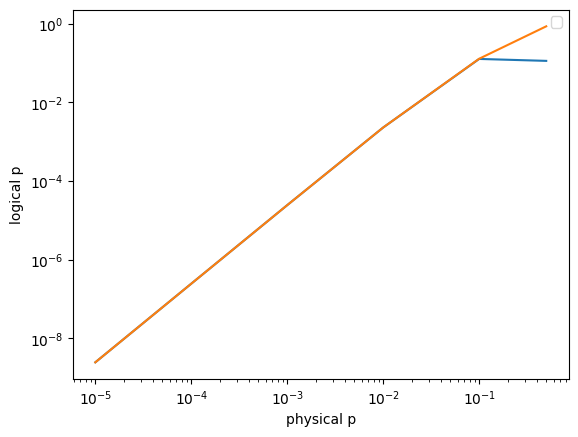

In [31]:
err_model = qs.noise.E1
q = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.5]
err_params = {'q': q}

ss_sam = qs.SubsetSampler(protocol=steane, simulator=qs.StimSimulator,  p_max={'q': 0.1}, err_model=err_model, err_params=err_params, L=3)
ss_sam.run(2000)

v1 = ss_sam.stats()[0]
w1 = ss_sam.stats()[2]

plt.plot(q,v1)
plt.plot(q,w1)
plt.xlabel('physical p')
plt.ylabel('logical p')
plt.xscale('log')
plt.yscale('log')
plt.legend()